# CROCUS Data Coverage

Historical uptime analysis for CROCUS Sage/Waggle nodes.
Use this notebook to document sensor availability over time, investigate
outages, and generate coverage figures for reports.

These cells make one API call per day per sensor — expect several minutes
for long date ranges.

- Sage Data Client: https://github.com/sagecontinuum/sage-data-client
- CROCUS Instrument Cookbooks: https://crocus-urban.github.io/instrument-cookbooks/

## Network Notes

- All CROCUS WXT and AQT nodes were offline approximately December 2025 – March 2026
  during a network-wide maintenance period.
- The 5-minute averaging plugin was deployed across all nodes when they came back
  online in April 2026. Historical data prior to this transition is at >1Hz.
- The AQT and WXT data in `sage_utils` is resampled to 5-minute means before
  returning, making it consistent across both the high-frequency and low-frequency
  periods.


In [1]:
# Standard library
import datetime as dt
import ssl

# Third party
import calplot
import matplotlib.pyplot as plt
import pandas as pd
import sage_data_client

# Local
import importlib
import crocus_sites
importlib.reload(crocus_sites)
import sage_utils
importlib.reload(sage_utils)
import coverage_utils
importlib.reload(coverage_utils)

from crocus_sites import (
    ALL_SITES,
    ATMOS, BIG, CCICS, CSU,
    HUM, NEIU, NU, SHEDD, UIC,
)
from sage_utils import last_n_hours
from coverage_utils import (
    check_status, plot_node_status,
    CANARY_VARIABLES, SENSOR_FLAGS,
)

ssl._create_default_https_context = ssl._create_unverified_context


## Sensor Sanity Checks

Quick cross-checks between sensors at a single site to validate readings.


In [2]:
start_cont, end = last_n_hours(6)

# BME680 temperature
df_bme = sage_data_client.query(
    start=start_cont,
    end=end,
    filter={
        'name':   'env.temperature',
        'vsn':    ATMOS.vsn,
        'sensor': 'bme680',
    },
    head=20
)

# AQT temperature
df_aqt = sage_data_client.query(
    start=start_cont,
    end=end,
    filter={
        'name': 'aqt.env.temp',
        'vsn':  ATMOS.vsn,
    },
    head=20
)

print(f"BME680 rows: {len(df_bme)}   AQT rows: {len(df_aqt)}")
print()

if not df_bme.empty and not df_aqt.empty:
    bme_mean = pd.to_numeric(df_bme['value'], errors='coerce').mean()
    aqt_mean = pd.to_numeric(df_aqt['value'], errors='coerce').mean()
    print(f"BME680 mean temp: {bme_mean:.2f} °C")
    print(f"AQT    mean temp: {aqt_mean:.2f} °C")
    print(f"Difference:       {bme_mean - aqt_mean:.2f} °C")
    if abs(bme_mean - aqt_mean) > 5:
        print("⚠️  Large discrepancy — BME may be inside enclosure")
    else:
        print("✓  Temperatures agree — BME likely in radiation shield")


BME680 rows: 0   AQT rows: 20



## Frequency Transition Investigation

All CROCUS nodes transitioned from >1Hz sampling to 5-minute averaged data
in April 2026 as part of a network-wide plugin update. The cells below
document how this was determined.


In [3]:
# Check whether meta.avg_frequency column is present — its presence indicates
# the 5-minute averaging plugin is active. Absence indicates >1Hz raw data.
# Uses a single canary variable and head=10 to keep queries fast.

for site in ALL_SITES:
    print(f'\n{site.abbr} ({site.vsn}):')
    for date in ['2025-12-01', '2026-01-01', '2026-02-01',
                 '2026-03-01', '2026-04-01', '2026-05-01']:
        df_test = sage_data_client.query(
            start=date,
            end=date[:10] + 'T01:00:00Z',
            filter={'name': 'wxt.env.temp', 'vsn': site.vsn},
            head=10
        )
        has_freq = 'meta.avg_frequency' in df_test.columns
        rows = len(df_test)
        print(f'  {date}: {rows} rows, avg_frequency: {has_freq}')



ATMOS (W0A4):
  2025-12-01: 10 rows, avg_frequency: False
  2026-01-01: 0 rows, avg_frequency: False
  2026-02-01: 0 rows, avg_frequency: False
  2026-03-01: 0 rows, avg_frequency: False
  2026-04-01: 10 rows, avg_frequency: True
  2026-05-01: 10 rows, avg_frequency: True

BIG (W0A0):
  2025-12-01: 10 rows, avg_frequency: False
  2026-01-01: 0 rows, avg_frequency: False
  2026-02-01: 0 rows, avg_frequency: False
  2026-03-01: 0 rows, avg_frequency: False
  2026-04-01: 10 rows, avg_frequency: True
  2026-05-01: 0 rows, avg_frequency: False

CCICS (W08B):
  2025-12-01: 10 rows, avg_frequency: False
  2026-01-01: 0 rows, avg_frequency: False
  2026-02-01: 0 rows, avg_frequency: False
  2026-03-01: 0 rows, avg_frequency: False
  2026-04-01: 10 rows, avg_frequency: True
  2026-05-01: 0 rows, avg_frequency: False

CSU (W08E):
  2025-12-01: 10 rows, avg_frequency: False
  2026-01-01: 0 rows, avg_frequency: False
  2026-02-01: 0 rows, avg_frequency: False
  2026-03-01: 0 rows, avg_frequency: 

## Daily Uptime Calendar

Calendar heatmap showing data availability for a single node and sensor type.
Green = data present, red = no data, gray = outside the query window.

Coverage is binary (up/down) rather than a count, making it robust to the
>1Hz to 5-minute frequency change in April 2026.

Each day requires one lightweight API call (head=3) — expect this to take
several minutes for long date ranges.


findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.
findfont: Font family 'Helvetica' not found.


Total days:     142
Days with data: 65


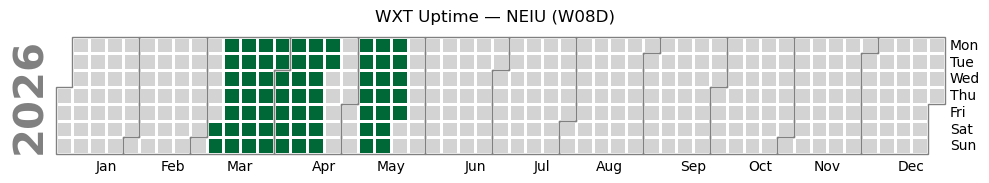

In [4]:
# Single node, single sensor type
# Adjust SITE, start, end, and sensor as needed

SITE   = NEIU
start  = '2026-01-01'
end    = '2026-05-22'
sensor = 'wxt'

status = check_status(SITE.vsn, start, end, sensor=sensor)

print(f'Total days:     {len(status)}')
print(f'Days with data: {int(status.sum())}')

fig, axes = calplot.calplot(
    status.tz_localize(None),
    how=None,
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    colorbar=False,
    fillcolor='lightgrey',
)
plt.suptitle(f'{sensor.upper()} Uptime — {SITE.abbr} ({SITE.vsn})',
             y=1.02, fontsize=12)
plt.show()


## All Sensors — Single Node

Calendar heatmap for every sensor type at one site.


In [ ]:
SITE  = NEIU
start = '2026-01-01'
end   = '2026-05-22'

for sensor in CANARY_VARIABLES:
    if not getattr(SITE, SENSOR_FLAGS[sensor], False):
        print(f"Skipping {sensor} — not configured at {SITE.abbr}")
        continue
    status = check_status(SITE.vsn, start, end, sensor=sensor)
    fig, axes = calplot.calplot(
        status.tz_localize(None),
        how=None,
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        colorbar=False,
        fillcolor='lightgrey',
    )
    plt.suptitle(f'{sensor.upper()} Uptime — {SITE.abbr} ({SITE.vsn})',
                 y=1.02, fontsize=12)
    plt.show()


## Multi-Node Uptime Comparison

Calendar heatmap for one sensor type across all CROCUS nodes.
Useful for distinguishing node-specific outages from network-wide events.
Change `sensor` to compare any sensor type.


In [ ]:
# One API call per day per node — slow for long ranges
start  = '2026-01-01'
end    = '2026-05-22'
sensor = 'wxt'

for site in ALL_SITES:
    if not getattr(site, SENSOR_FLAGS[sensor], False):
        print(f"Skipping {site.abbr} — {sensor} not configured")
        continue
    status = check_status(site.vsn, start, end, sensor=sensor)
    fig, axes = calplot.calplot(
        status.tz_localize(None),
        how=None,
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        colorbar=False,
        fillcolor='lightgrey',
    )
    plt.suptitle(f'{sensor.upper()} Uptime — {site.abbr} ({site.vsn})',
                 y=1.02, fontsize=12)
    plt.show()
